# Statistische Qualitätskontrolle



Dieses Jupyter-Notebook enthält Python-Code zur Berechnung von Stichprobenplänen für die statistische Qualitätskontrolle.

Siehe auch [Statistische Qualitätskontrolle Webapp](https://a-herzog.github.io/QC/).

## Vorbereitung und Hilfsfunktionen

## Einbinden der notwendigen Bibliotheken

In [10]:
from math import floor, ceil, factorial, exp
from scipy.special import binom
from scipy.stats import chi2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as patches
from collections.abc import Callable

plt.style.use('seaborn-v0_8')

### Plotten der Operationscharakteristik

In [11]:
def plot_L(L: Callable[[float], float], title: str, N: float | None = None, n: float | None = None, AQL: tuple[float, float] | None = None, LQ: tuple[float, float] | None = None, steepness: tuple[float, float] | None = None) -> None:
    """Plotten der Operationscharakteristik-Funktion.

    Args:
        L (Callable[[float], float]): Operationscharakteristik-Funktion.
        title (str): Titel des Plots.
        N (float | None, optional): Liefergröße. Defaults to None.
        n (float | None, optional): Stichprobengröße. Defaults to None.
        AQL (tuple[float, float] | None, optional): AQL. Defaults to None.
        LQ (tuple[float, float] | None, optional): LQ. Defaults to None.
        steepness (tuple[float, float] | None, optional): Indifferenzpunkt und Steilheit an dieser Stelle. Defaults to None.
    """
    p = np.linspace(0, 0.5, 100)
    L_values = np.vectorize(L)(p)
    slip_through_values = L_values * p

    fig, ax = plt.subplots()
    lns1 = ax.plot(p, L_values, color='blue', label='Annahmewahrscheinlichkeit')
    lns2 = ax.plot(p, slip_through_values, color='magenta', linestyle='dashed', label='Mittlerer Durchschlupf')

    ax.set_title(title)
    ax.set_xlabel("Ausschussrate")
    ax.set_ylabel("Annahmewahrscheinlichkeit / Durchschlupf")
    ax.xaxis.set_major_formatter(ticker.PercentFormatter(1))
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(1))

    if AQL is not None and LQ is not None:
        points = tuple(zip(AQL, LQ))
        ax.scatter(points[0], points[1], color=['green', 'red'])
        ax.add_patch(patches.Rectangle((0, 1), AQL[0], -(1 - AQL[1]), linewidth=0, facecolor='green', alpha=0.4))
        ax.add_patch(patches.Rectangle((LQ[0], LQ[1]), 0.5 - LQ[0], -LQ[1], linewidth=0, facecolor='red', alpha=0.4))

    if steepness is not None:
        p50percent = steepness[0]
        h0 = steepness[1]
        plt.scatter([p50percent], [0.5], color=['red'])
        dL = -h0 / 2 / p50percent
        x = np.linspace(max(0, p50percent - 0.025), min(0.5, p50percent + 0.025))
        y = 0.5 + (x - p50percent) * dL
        plt.plot(x, y, color='red')

    if N is not None and n is not None:
        testing_effort = n * L_values + N * (1 - L_values)
        ax2 = plt.twinx()
        lns3 = ax2.plot(p[0:len(p) * 2 // 3], testing_effort[0:len(p) * 2 // 3], color='green', linestyle='dotted', label='Average testing effort')  # pyright: ignore[reportAttributeAccessIssue]
        ax2.set_ylabel("Mittlerer Prüfaufwand")
        ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

        lns = lns1 + lns2 + lns3
        labs = [l.get_label() for l in lns]
        plt.legend(lns, labs, loc=0)
    else:
        plt.legend(loc=0)

### AQL und LQ prüfen

In [12]:
def test_AQL(L: Callable[[float], float], AQL: tuple[float, float]) -> bool:
    """Prüft ob die Operationcharakteristik die AQL.

    Args:
        L (Callable[[float], float]): Operationscharakteristik-Funktion.
        AQL (tuple[float, float]): AQL.

    Returns:
        bool: Gibt True zurück, wenn die Operationscharakteristik die AQL erfüllen.
    """
    return L(AQL[0]) >= AQL[1]

def test_LQ(L: Callable[[float], float], LQ: tuple[float, float]) -> float:
    """Prüft ob die Operationcharakteristik die LQ.

    Args:
        L (Callable[[float], float]): Operationscharakteristik-Funktion.
        LQ (tuple[float, float]): LQ.

    Returns:
        bool: Gibt True zurück, wenn die Operationscharakteristik die LQ erfüllen.
    """
    return L(LQ[0]) <= LQ[1]

def test_plan(L: Callable[[float], float], AQL: tuple[float, float], LQ: tuple[float, float]) -> float:
    """Prüft ob die Operationcharakteristik die AQL und die LQ.

    Args:
        L (Callable[[float], float]): Operationscharakteristik-Funktion.
        AQL (tuple[float, float]): AQL.
        LQ (tuple[float, float]): LQ.

    Returns:
        bool: Gibt True zurück, wenn die Operationscharakteristik sowohl die AQL als auch die LQ erfüllen.
    """
    return test_AQL(L, AQL) and test_LQ(L, LQ)

### Operationscharakteristik-Funktion auf Basis verschiedener Wahrscheinlichkeitsverteilungen

In [13]:
def L_Hg(N: int, n: int, c: int, p: float) -> float:
    """Operationcharakteristik bei Verwendung der hypergeometrischen Verteilung zur Modellierung der Stichprobe.

    Args:
        N (int): Liefergröße.
        n (int): Stichprobengröße.
        c (int): Anzahl an maximal zulässigen Ausschussanteilen in der Stichprobe.
        p (float): Ausschussrate.

    Returns:
        float: Annahmewahrscheinlichkeit.
    """
    R = floor(N * p)
    return np.sum([binom(R, k) * binom(N - R, n - k) / binom(N, n) for k in range(c + 1)])


def L_B(n: int, c: int, p: float) -> float:
    """Operationcharakteristik bei Verwendung der Binomialverteilung zur Modellierung der Stichprobe.

    Args:
        n (int): Stichprobengröße.
        c (int): Anzahl an maximal zulässigen Ausschussanteilen in der Stichprobe.
        p (float): Ausschussrate.

    Returns:
        float: Annahmewahrscheinlichkeit.
    """
    return np.sum([binom(n, k)*p**k*(1-p)**(n-k) for k in range(c + 1)])


def L_P(n: int, c: int, p: float) -> float:
    """Operationcharakteristik bei Verwendung der Poisson-Verteilung zur Modellierung der Stichprobe.

    Args:
        n (int): Stichprobengröße.
        c (int): Anzahl an maximal zulässigen Ausschussanteilen in der Stichprobe.
        p (float): Ausschussrate.

    Returns:
        float: Annahmewahrscheinlichkeit.
    """
    lmbda = n * p
    return np.sum([lmbda**k / factorial(k) * exp(-lmbda) for k in range(c + 1)])

## Darstellung der Operationscharakteristik

True

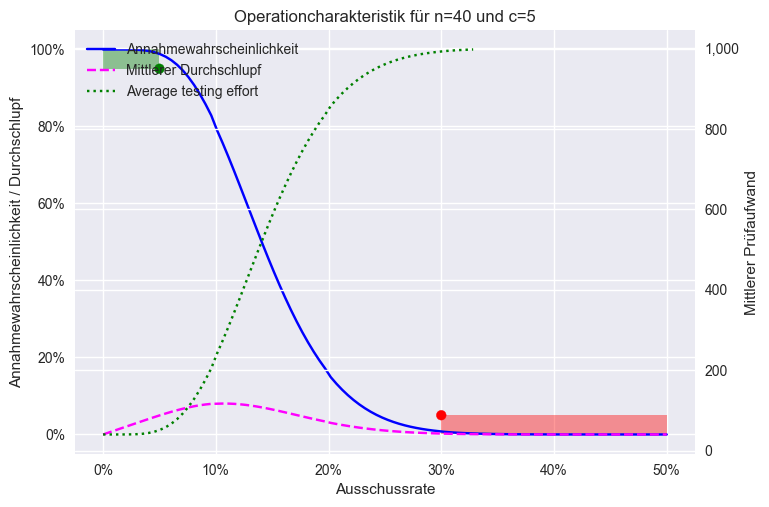

In [14]:
# Liefergröße
N = 1000

# Gut- und Schlechtgrenze
AQL = (0.05, 0.95)  # Lieferungen mit maximal 5 % fehlerhaften Teilen sollten mit einer Wahrscheinlichkeit von mindestens 95 % angenommen werden.
LQ = (0.3, 0.05)  # Lieferungen mit über 30 % fehlerhaften Teilen sollten mit einer Wahrscheinlichkeit von höchstens noch 5 % angenommen werden.

# Stichprobenplan
n = 40
c = 5

# Operationcharakteristik-Funktion
def L(p): return L_Hg(N, n, c, p)

# Plotten der Operationcharakteristik
plot_L(L, f"Operationcharakteristik für n={n} und c={c}", N, n, AQL, LQ)

# Erfüllt der Stichprobenplan die Gut- und die Schlechtgrenze?
test_plan(L, AQL, LQ)

## Algorithmus von Günther

Optimalen Stichprobenplan gefunden: n = 24 , c = 3


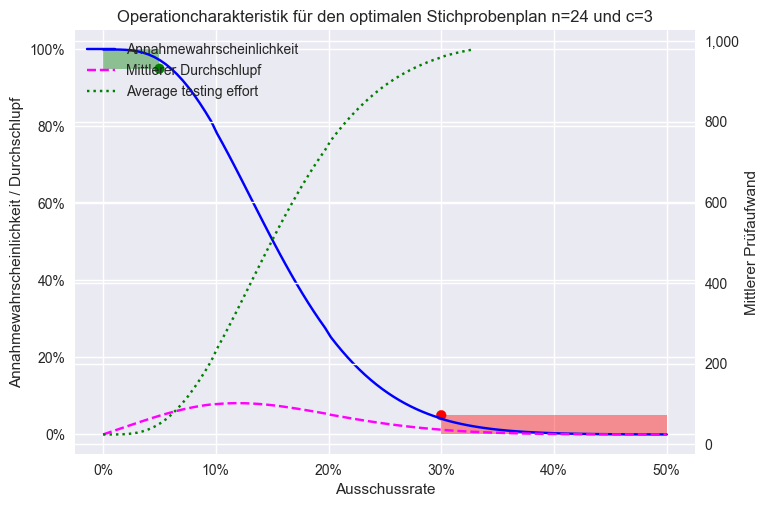

In [15]:
# Liefergröße
N = 1000

# Gut- und Schlechtgrenze
AQL = (0.05, 0.95)  # Lieferungen mit maximal 5 % fehlerhaften Teilen sollten mit einer Wahrscheinlichkeit von mindestens 95 % angenommen werden.
LQ = (0.3, 0.05)  # Lieferungen mit über 30 % fehlerhaften Teilen sollten mit einer Wahrscheinlichkeit von höchstens noch 5 % angenommen werden.

# Initialer Stichprobenplan
n = 1
c = 0

# Erfült der initiale Stichprobenplan bereits die Gut- und die Schlechtgrenze?
done = False
if test_plan(lambda p: L_Hg(N, n, c, p), AQL, LQ):
    print("Optimal plan found: n =", n, ", c =", c)
    done = True

# Äußere Schleife: Über c iterieren
if not done:
    while True:
        # Innere Schleife: Über n iterieren
        while not test_LQ(lambda p: L_Hg(N, n, c, p), LQ):
            n += 1
        if test_AQL(lambda p: L_Hg(N, n, c, p), AQL):
            print("Optimalen Stichprobenplan gefunden: n =", n, ", c =", c)
            break
        c += 1
        n = c

# Operationcharakteristik für optimalen Stichprobenplan plotten
plot_L(lambda p: L_Hg(N, n, c, p), f"Operationcharakteristik für den optimalen Stichprobenplan n={n} und c={c}", N, n, AQL, LQ)

## $\chi^2$-Methode

Optimalen Stichprobenplan gefunden: n = 26 , c = 3


True

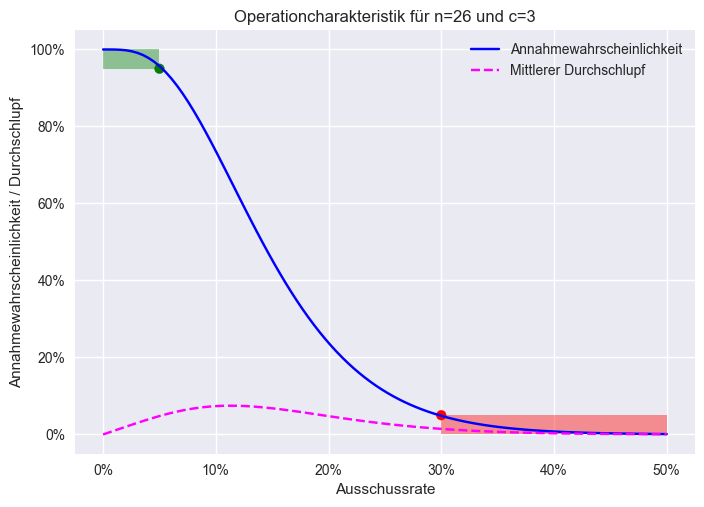

In [16]:
# Gut- und Schlechtgrenze
AQL = (0.05, 0.95)  # Lieferungen mit maximal 5 % fehlerhaften Teilen sollten mit einer Wahrscheinlichkeit von mindestens 95 % angenommen werden.
LQ = (0.3, 0.05)  # Lieferungen mit über 30 % fehlerhaften Teilen sollten mit einer Wahrscheinlichkeit von höchstens noch 5 % angenommen werden.

c = 0
while True:
    n = ceil(chi2.ppf(1 - LQ[1], 2 * (c + 1)) / (2 * LQ[0]))
    n2 = floor(chi2.ppf(1 - AQL[1], 2 * (c + 1)) / (2 * AQL[0]))
    if n <= n2:
        print("Optimalen Stichprobenplan gefunden: n =", n, ", c =", c)
        break
    c += 1

# Operationcharakteristik-Funktion
def L(p): return L_P(n, c, p)

# Operationcharakteristik plotten
plot_L(L, f"Operationcharakteristik für n={n} und c={c}", AQL=AQL, LQ=LQ)

# Erfüllt der Stichprobenplan die Gut- und die Schlechtgrenze?
test_plan(L, AQL, LQ)

## Philips Stichprobenplan

Optimalen Stichprobenplan gefunden: n = 67 , c = 6


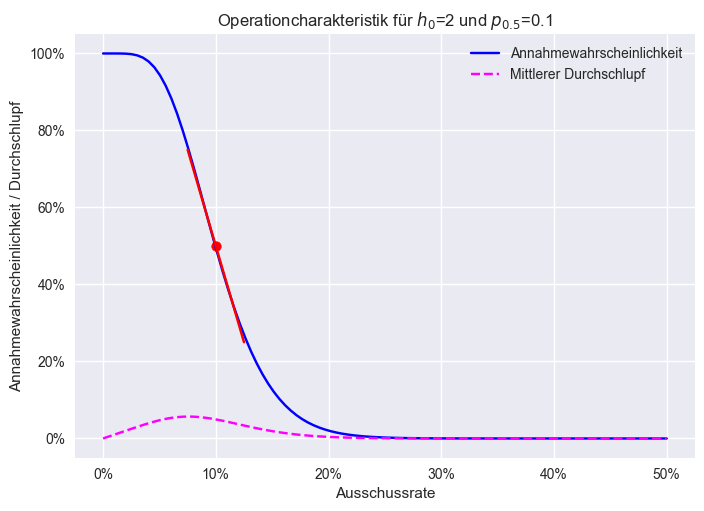

In [17]:
# Steilheit am Indifferenzpunkt
h0 = 2

# Indifferenzpunkt
p50percent = 0.1

c = 0
while True:
    n = ceil(chi2.ppf(0.5, 2 * (c + 1)) / (2 * p50percent))
    if 2 * (n * p50percent)**(c + 1) / factorial(c) * exp(-n * p50percent) >= h0:
        print("Optimalen Stichprobenplan gefunden: n =", n, ", c =", c)
        break
    c += 1

# Operationcharakteristik-Funktion
def L(p): return L_P(n, c, p)

# Operationcharakteristik plotten
plot_L(L, f"Operationcharakteristik für $h_0$={h0} und $p_{{0.5}}$={p50percent}", steepness=(p50percent, h0))